In [ ]:
#| default_exp prob_forecasting

## Probabilistic Forecasting

peshbeen provides native support for probabilistic forecasting, allowing users to obtain not only point forecasts but also prediction intervals and full forecast scenarios. For any model in the library, prediction intervals are generated by calibrating the model's residuals on a held-out calibration set, then using those calibrated residuals to simulate future paths of the series — giving a realistic picture of forecast uncertainty rather than a single optimistic trajectory.
peshbeen supports four calibration methods: bootstrapping, correlated error bootstrapping, KDE-based sampling, and conformal prediction. The first three support both prediction intervals and scenario generation; conformal prediction is limited to prediction intervals only.

In [ ]:
import pandas as pd
import numpy as np
from peshbeen.transformations import fourier_terms
date_range = pd.date_range(start='2020-01-01', periods=720, freq='D')
# create a non-stationary arbitrary flower sales data with an upward trend, weekly seasonality, and yearly seasonality
np.random.seed(42)
data = 30 + 0.07 * np.arange(720) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 7) + 10 * np.sin(2 * np.pi * date_range.dayofyear / 365) + np.random.normal(0, 5, 720)

sales_data = pd.DataFrame(data, index=date_range, columns=['sales'])
sales_data['day_of_week'] = sales_data.index.dayofweek

fourier_trms = fourier_terms(index=sales_data.index, period=365, num_terms=2)
sales_data = sales_data.merge(fourier_trms, left_index=True, right_index=True) # merge the fourier terms with the original data to be used as exogenous variables in the model

# split the data into train and test
train = sales_data.iloc[:-30]
test = sales_data.iloc[-30:] # drop the target column from the exogenous variables for the test set
cat_vars = ['day_of_week']

from peshbeen.models import ml_forecaster
from peshbeen.probabilistic_forecasting import prob_forecasts
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")

# lets use our sales_exog dataset to generate probabilistic forecasts using the linear regression model we fitted with fourier terms as exogenous variables. We will use the bootstrapping method to generate prediction intervals and forecast scenarios, which will allow us to capture the uncertainty in our forecasts and provide a range of possible future outcomes based on the variability in the historical data. This approach is particularly useful for decision-making and risk assessment, as it gives us insights into the potential variability in future sales rather than just a single point forecast. We will then visualize the prediction intervals and scenarios to better understand the uncertainty around our forecasts.
# first create a model instance with the same specifications as the one we used to generate point forecasts, but without fitting it yet
lr_model = ml_forecaster(model=LinearRegression(),
              target_col='sales', lags = 7, cat_variables=cat_vars, categorical_encoder=ohe)
lr_model.fit(train)
lr_forecast = lr_model.forecast(H=30, exog=test.drop(columns=['sales'])) # generate point forecasts for the test set using the fitted linear regression model with fourier terms as exogenous variables
prob_model = prob_forecasts(model=lr_model, H=30, n_calibration=150, step_size=1, random_state=42)
## Generate 1000 forecast scenarios using the KDE-based sampling method, which will allow us to capture the uncertainty in our forecasts and provide a range of possible future outcomes based on the variability in the historical data. We will use the exogenous variables from the test set to generate these scenarios, which will help us understand how different future paths of the series can evolve given the uncertainty in the data and the model.
prob_samples = prob_model.sample(df=train, n_samples=1000, method="empirical", future_exog=test.drop(columns=['sales'])) # empirical method, which generates forecast scenarios by sampling from the empirical distribution of the residuals, allowing us to capture the variability in the historical data and provide a range of possible future outcomes based on that distribution. By using the exogenous variables from the test set, we can also account for any future changes in those variables that may impact the forecasts, providing a more realistic picture of potential future scenarios.
# other options for method are "kde" and "correlated" for both prediction intervals and scenarios; conformal prediction (via calibrate() + conformal_quantiles()) is for prediction intervals only. Each method has its own assumptions and characteristics, so it's recommended to try different methods to see which one captures the uncertainty in the forecasts better for your specific dataset and use case.
# prob_samples = prob_model.sample(df=train, n_samples=1000, method="kde", future_exog=test.drop(columns=["sales"]))   # KDE-based sampling
# prob_samples = prob_model.sample(df=train, n_samples=1000, method="correlated", future_exog=test.drop(columns=["sales"]))   # correlated (cross-horizon) bootstrap

In [ ]:
scenarios_df = prob_samples.sample_paths_df
scenarios_df.head()

,h_1,h_2,h_3,h_4,h_5,h_6,h_7,h_8,h_9,h_10,...,h_21,h_22,h_23,h_24,h_25,h_26,h_27,h_28,h_29,h_30
0,70.203125,68.211784,61.222973,47.457646,81.232649,77.495237,87.476730,71.192629,67.034386,60.305736,...,85.838524,75.784002,69.753410,69.731598,72.669514,79.870773,93.659278,88.009088,87.464328,74.435822
1,78.691134,74.740641,61.016970,83.559826,90.572751,87.953672,96.814063,79.939854,64.572440,68.788660,...,74.970377,72.838277,68.561255,64.933742,77.445978,67.482043,91.776537,91.707965,76.203132,75.481506
2,82.069878,61.770775,67.900598,67.495120,69.749580,79.239796,79.836127,66.879103,66.755009,66.691565,...,87.017650,64.417982,75.878479,80.253700,79.177897,83.927480,84.239859,69.757712,78.160331,66.422037
3,80.346174,66.091816,61.401799,62.789824,72.857167,83.558991,80.061408,81.668895,72.644718,67.219090,...,76.933844,69.719599,61.166186,64.933742,68.640012,87.175191,81.238305,91.028212,69.380568,75.335512
4,66.752091,64.230679,62.686489,67.053262,67.114281,83.131232,77.014338,61.557219,69.843805,53.361732,...,78.910478,70.907761,81.000763,74.934948,66.045678,90.214074,83.649049,88.001431,85.495248,72.394421


In [ ]:
# we can also generate prediction intervals from the generated scenarios using the sample_quantiles attribute of the prob_samples object, which gives us the quantiles of the simulated forecast paths and allows us to visualize the uncertainty around our forecasts in the form of prediction intervals.
prediction_intervals = prob_samples.sample_quantiles(quantiles=[0.1, 0.9])
prediction_intervals.head()

,point_forecast,q_10,q_90
0,75.106952,69.030466,81.959195
1,66.339791,59.629132,75.143235
2,62.027001,55.553265,69.990028
3,64.862720,58.447102,72.892975
4,74.599564,68.215537,83.387642


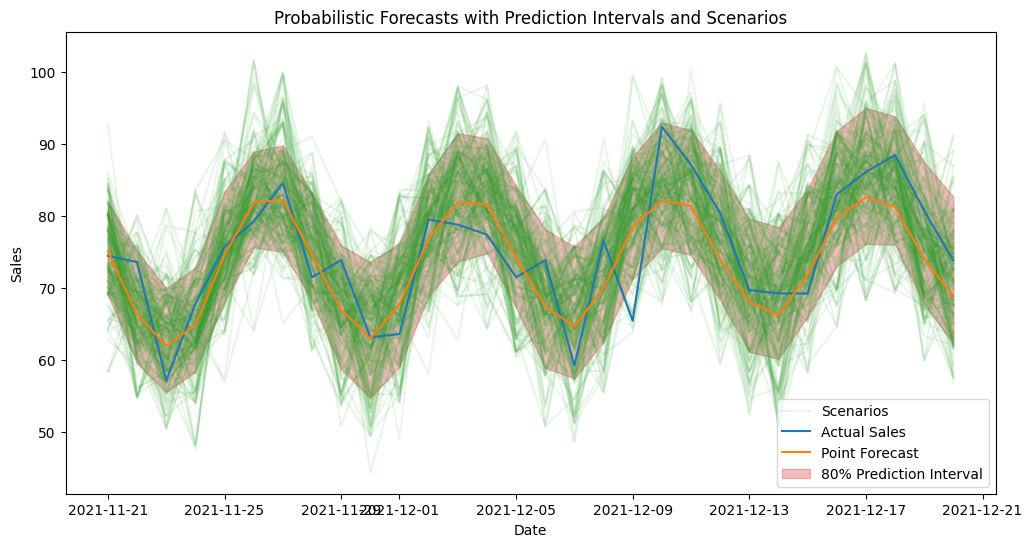

In [ ]:

# lets visualize the prediction intervals and 15 scenarios from the generated probabilistic forecasts to understand the uncertainty around our forecasts and the range of possible future outcomes based on the variability in the historical data. This visualization will help us see how the forecasted values can vary and provide insights into potential risks and opportunities for decision-making.
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
# plot 201 scenarios
for i in range(200):
    plt.plot(test.index, scenarios_df.iloc[i], color='C2', alpha=0.1)
plt.plot(test.index, scenarios_df.iloc[100], color='C2', alpha=0.1, label='Scenarios') # added for labeling the scenarios in the legend
plt.plot(test.index, test['sales'], label='Actual Sales', color='C0')
plt.plot(test.index, lr_forecast, label='Point Forecast', color='C1')
# plot the prediction intervals we generated from the scenarios
plt.fill_between(test.index, prediction_intervals["q_10"], prediction_intervals["q_90"], color='C3', alpha=0.3, label='80% Prediction Interval')
plt.title('Probabilistic Forecasts with Prediction Intervals and Scenarios')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

One concern with bootstrapping residuals is that it assumes the residuals are independent and identically distributed (i.i.d.), which may not hold in time series data where residuals can exhibit autocorrelation. To address this, peshbeen offers correlated error bootstrapping, which preserves the temporal dependence structure of the residuals by resampling blocks of consecutive residuals rather than individual residuals. This method may provide more accurate prediction intervals and scenarios when there is significant autocorrelation in the residuals.

Also, KDE-based sampling allows for a non-parametric estimation of the residual distribution, which can capture more complex patterns in the residuals compared to simple bootstrapping. This can lead to more accurate and realistic forecast scenarios, especially when the residuals exhibit non-normality or heteroscedasticity.

To obtain probabilistic forecasts via correlated error bootstrapping and KDE-based sampling, user can simply pass `method="correlated"` or `method="kde"` to the `sample` method of the `prob_forecasts` object, along with the training and future exogenous variables if applicable.

### Conformal Prediction

Conformal prediction is a powerful technique for generating valid prediction intervals without making strong assumptions about the underlying data distribution. This method is particularly useful when the residuals do not follow a normal distribution or when there is heteroscedasticity in the data, as it provides robust and reliable prediction intervals based on the empirical distribution of the residuals. As conformal prediction does not rely on bootstrapping or density estimation, it does not support scenario generation, but it can be a valuable tool for obtaining accurate prediction intervals.

We can call `.conformal_quantiles` after `sample` to obtain conformal prediction intervals for the desired quantiles, which will be based on the empirical distribution of the residuals from the calibration set. But since conformal prediction does not support scenario generation, we do not need to first call `sample`. Instead, we can first calibrate the model using the `calibrate` method, which will compute the residuals on the calibration set and store them for later use in conformal prediction. Then, we can call `.conformal_quantiles` directly to obtain the prediction intervals for the specified quantiles, without needing to generate forecast scenarios.

In [ ]:
from xgboost import XGBRegressor
xgb_model = ml_forecaster(model=XGBRegressor(n_estimators=100, max_depth=5, random_state=42),
              target_col='sales', lags = 7, box_cox=0.5)
# xgb_model.fit(train_exog)
prob_model = prob_forecasts(model=xgb_model, H=30, n_calibration=150, step_size=1, random_state=42)
# 
prob_model.calibrate(df=train)
conformal_predictions = prob_model.conformal_quantiles(df=train, quantiles=[0.1, 0.9], future_exog=test.drop(columns=['sales']))
conformal_predictions.head()

,point_forecast,q_10,q_90
0,74.912277,66.090329,83.734225
1,66.425034,57.871811,74.978256
2,54.184700,45.567349,62.802051
3,60.703491,51.632639,69.774344
4,65.144173,56.466028,73.822317


> What if there isn't enough data to set aside a separate calibration set? In that case, in-sample residuals can be used instead — but with an important caveat: since the model is evaluated on the data it was trained on, the resulting prediction intervals will likely be optimistic, underestimating true forecast uncertainty. This is particularly true when the model overfits, as in-sample residuals will not fully reflect the variability the model will encounter on unseen data. That said, it is a practical and computationally efficient option when data is limited, as it avoids holding out any observations from training.


> Note that correlated error bootstrapping is not available for in-sample residuals, as its procedure relies on horizon-dependent error structure that cannot be derived from in-sample fit alone.

In [ ]:
from sklearn.linear_model import Lasso
lr_model = ml_forecaster(model=Lasso(alpha=0.1, random_state=42),
              target_col='sales', lags = 21, box_cox=0.5)
prob_model_insample = prob_forecasts(model=lr_model, H=30, n_calibration=None, random_state=42) # Just leave n_calibration as None to use the training data for calibration
prob_samples = prob_model_insample.sample(df=train, n_samples=1000, method="kde", future_exog=test.drop(columns=['sales'])) # generate in-sample forecast scenarios using the KDE-based sampling method, which will allow us to capture the uncertainty in our forecasts and provide a range of possible future outcomes based on the variability in the historical data. By using the exogenous variables from the test set, we can also account for any future changes in those variables that may impact the forecasts, providing a more realistic picture of potential future scenarios.

prob_samples.sample_quantiles(quantiles=[0.1, 0.9]).head()

,point_forecast,q_10,q_90
0,73.441562,64.805654,80.478289
1,67.889286,59.253379,74.926013
2,63.400497,54.764589,70.437224
3,65.285133,56.649225,72.321860
4,71.037142,62.401234,78.073869


### Correlated (cross-horizon) bootstrap in action

The `empirical` and `kde` methods resample residuals independently at each horizon, which can understate the *joint* uncertainty of a multi-step path. The `correlated` method instead fits a multivariate normal to the full H-dimensional residual vectors, so a sample path that is high at horizon 1 tends to stay high at horizon 2 — preserving the horizon-to-horizon dependence that matters for downstream simulation (e.g. cumulative demand over a week). Below we regenerate scenarios with `method="correlated"` and overlay the interval.

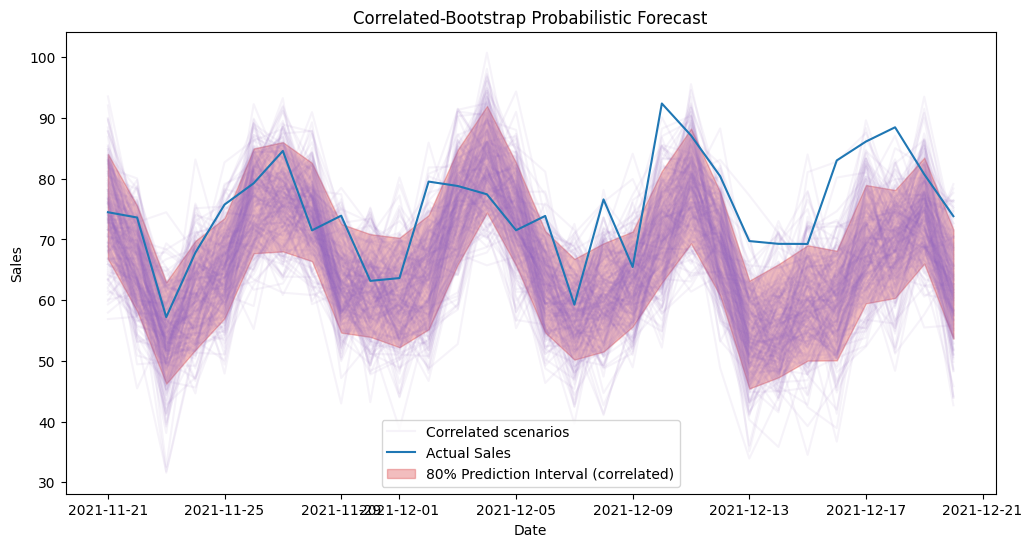

In [ ]:
# Re-use the calibrated linear model from the start of the notebook.
corr_samples = prob_model.sample(df=train, n_samples=1000, method="correlated",
                                 future_exog=test.drop(columns=['sales']))

corr_scenarios = corr_samples.sample_paths_df
corr_intervals = corr_samples.sample_quantiles(quantiles=[0.1, 0.9])

plt.figure(figsize=(12, 6))
for i in range(200):
    plt.plot(test.index, corr_scenarios.iloc[i], color='C4', alpha=0.08)
plt.plot(test.index, corr_scenarios.iloc[0], color='C4', alpha=0.08, label='Correlated scenarios')
plt.plot(test.index, test['sales'], label='Actual Sales', color='C0')
plt.fill_between(test.index, corr_intervals["q_10"], corr_intervals["q_90"],
                 color='C3', alpha=0.3, label='80% Prediction Interval (correlated)')
plt.title('Correlated-Bootstrap Probabilistic Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

### Probabilistic forecasting for multivariate models

The same machinery works for the multivariate forecasters (`var`, `ml_mv_forecaster`, `ms_var`) through `mv_prob_forecasts`. Because a multivariate model forecasts several series at once, you tell the wrapper **which target series** to build the predictive distribution for via the `target_col` argument; everything else (`sample`, `sample_quantiles`, `calibrate`, `conformal_quantiles`) mirrors the univariate API.

In [ ]:
from peshbeen.models import var
from peshbeen.probabilistic_forecasting import mv_prob_forecasts

# Build a small multivariate dataset (sales / marketing / advertising).
np.random.seed(0)
mv_index = pd.date_range(start='2020-01-01', periods=600, freq='D')
doy = mv_index.dayofyear.to_numpy()
mv = pd.DataFrame({
    'sales':       120 + 0.1*np.arange(600) + 5*np.sin(2*np.pi*doy/7) + np.random.normal(0, 2, 600),
    'marketing':    80 + 0.07*np.arange(600) + 3*np.sin(2*np.pi*doy/7) + np.random.normal(0, 2, 600),
    'advertising':  50 + 0.03*np.arange(600) + 1*np.sin(2*np.pi*doy/7) + np.random.normal(0, 2, 600),
}, index=mv_index)
mv['day_of_week'] = mv.index.dayofweek
mv_train, mv_test = mv.iloc[:-30], mv.iloc[-30:]

mv_ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
mv_model = var(target_cols=['sales', 'marketing', 'advertising'],
               lags={'sales': 7, 'marketing': [1, 7], 'advertising': 5},
               cat_variables=['day_of_week'], categorical_encoder=mv_ohe)

# Probabilistic forecast for the 'sales' series.
mv_prob = mv_prob_forecasts(model=mv_model, target_col='sales', H=30,
                            n_calibration=100, step_size=1, random_state=42)
mv_samples = mv_prob.sample(df=mv_train, n_samples=500, method="empirical",
                            future_exog=mv_test[['day_of_week']])
mv_samples.sample_quantiles(quantiles=[0.1, 0.5, 0.9]).head()

,point_forecast,q_10,q_50,q_90
0,180.183076,177.521624,179.985472,183.259075
1,178.358964,175.316912,178.291448,182.854870
2,175.423334,172.655740,175.192342,178.461429
3,173.129286,170.336371,172.945356,177.417477
4,175.573579,172.723777,175.704099,179.893574
